<a href="https://colab.research.google.com/github/NandanaRN/Natural_Language_Processing/blob/main/PROJECT_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Project 10: Banking Complaint Analysis

## Problem Statement

A bank receives customer complaints related to transactions, loans, online banking services, and account management through emails and support portals. Due to the high volume of complaints, customer support teams find it difficult to manually review and categorize every issue quickly.

This project develops an NLP-based banking complaint analysis system that preprocesses customer complaints, categorizes them into different banking issues, identifies frequent problems, and generates an analytical report to help improve customer service efficiency.

## Objectives

1. Create a banking complaint dataset.
2. Preprocess customer complaint text.
3. Categorize complaints into banking-related categories.
4. Identify frequent banking issues.
5. Build an NLP classification model.
6. Generate an analytical report.

## 1. Import Required Libraries

The following Python libraries are used for data handling, text preprocessing, visualization, and machine learning.

In [36]:
import pandas as pd
import numpy as np
import re
import string
import random

import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 2. Creating the Banking Complaint Dataset

Since a banking complaint dataset is not provided, a synthetic dataset is created for this project.

The complaints cover common banking problems such as:

- Transaction Issues
- Loan Issues
- Online Banking Issues
- Account Management
- Card Issues
- Fraud and Security
- ATM Issues
- Customer Service

In [37]:
complaints = [

# Transaction Issues
("My money was deducted but the transaction failed", "Transaction Issue"),
("The amount was debited from my account but the receiver did not get it", "Transaction Issue"),
("My UPI transaction failed but money was deducted", "Transaction Issue"),
("I made a payment yesterday but it is still showing as pending", "Transaction Issue"),
("The bank charged me twice for the same transaction", "Transaction Issue"),
("My online payment was unsuccessful but the amount was deducted", "Transaction Issue"),
("The transaction is still pending after several hours", "Transaction Issue"),
("Money was deducted from my account during a failed payment", "Transaction Issue"),
("I have not received the refund for my failed transaction", "Transaction Issue"),
("The payment was reversed but the money has not returned", "Transaction Issue"),

# Loan Issues
("My loan application has been pending for many days", "Loan Issue"),
("I want to know why my personal loan was rejected", "Loan Issue"),
("The interest rate on my loan is very high", "Loan Issue"),
("I have not received my approved loan amount", "Loan Issue"),
("My EMI amount is incorrect", "Loan Issue"),
("I want to change my loan repayment date", "Loan Issue"),
("The bank has charged extra interest on my loan", "Loan Issue"),
("I need information about my loan eligibility", "Loan Issue"),
("My loan approval is taking too long", "Loan Issue"),
("I want to close my existing loan", "Loan Issue"),

# Online Banking
("I cannot login to my internet banking account", "Online Banking"),
("The mobile banking application keeps crashing", "Online Banking"),
("I forgot my internet banking password", "Online Banking"),
("The banking app is not opening", "Online Banking"),
("I am unable to reset my online banking password", "Online Banking"),
("My mobile banking service is not working", "Online Banking"),
("The OTP is not arriving while trying to login", "Online Banking"),
("I cannot access my account through the banking application", "Online Banking"),
("The website shows an error when I try to login", "Online Banking"),
("Internet banking has stopped working", "Online Banking"),

# Account Management
("I want to update my registered mobile number", "Account Management"),
("How can I change my address in my bank account", "Account Management"),
("I want to close my savings account", "Account Management"),
("My account has been blocked", "Account Management"),
("I need to update my personal information", "Account Management"),
("I want to change my email address linked to my account", "Account Management"),
("Why has my bank account been frozen", "Account Management"),
("I want to open a new savings account", "Account Management"),
("My account details are incorrect", "Account Management"),
("I need help updating my account information", "Account Management"),

# Card Issues
("My debit card is not working", "Card Issue"),
("My credit card payment was declined", "Card Issue"),
("I lost my debit card and want to block it", "Card Issue"),
("My card has expired and I need a new one", "Card Issue"),
("The ATM card is damaged", "Card Issue"),
("My new debit card has not arrived", "Card Issue"),
("I want to increase my card limit", "Card Issue"),
("My credit card was declined during payment", "Card Issue"),
("I need to replace my lost card", "Card Issue"),
("My card is not being accepted at stores", "Card Issue"),

# Fraud and Security
("There is an unauthorized transaction in my account", "Fraud and Security"),
("Someone has used my card without permission", "Fraud and Security"),
("I received a suspicious transaction alert", "Fraud and Security"),
("Money was transferred from my account without my knowledge", "Fraud and Security"),
("I think my bank account has been hacked", "Fraud and Security"),
("There is a payment that I did not make", "Fraud and Security"),
("I received an OTP for a transaction I did not initiate", "Fraud and Security"),
("My card details may have been stolen", "Fraud and Security"),
("Someone made an unauthorized withdrawal", "Fraud and Security"),
("I want to report a fraudulent transaction", "Fraud and Security"),

# ATM Issues
("The ATM did not dispense cash but my account was debited", "ATM Issue"),
("My cash withdrawal failed", "ATM Issue"),
("The ATM kept my debit card", "ATM Issue"),
("I was charged a fee for withdrawing cash", "ATM Issue"),
("The ATM is not accepting my card", "ATM Issue"),
("I could not withdraw money from the ATM", "ATM Issue"),
("The ATM gave me less cash than requested", "ATM Issue"),
("Cash was not received but the withdrawal shows in my account", "ATM Issue"),
("The ATM machine is not working", "ATM Issue"),
("My card was retained by the ATM", "ATM Issue"),

# Customer Service
("I have been waiting for customer support for a long time", "Customer Service"),
("Nobody has responded to my complaint", "Customer Service"),
("I want to speak to a customer service representative", "Customer Service"),
("My previous complaint has not been resolved", "Customer Service"),
("The support team has not contacted me", "Customer Service"),
("I am unhappy with the customer service", "Customer Service"),
("I have not received any response from the bank", "Customer Service"),
("My complaint was closed without resolving my issue", "Customer Service"),
("I need immediate assistance from customer support", "Customer Service"),
("The bank has not provided a solution to my problem", "Customer Service")
]

df = pd.DataFrame(complaints, columns=["complaint", "category"])

print("Dataset created successfully!")
print("Number of complaints:", len(df))

df.head()

Dataset created successfully!
Number of complaints: 80


,complaint,category
0,My money was deducted but the transaction failed,Transaction Issue
1,The amount was debited from my account but the...,Transaction Issue
2,My UPI transaction failed but money was deducted,Transaction Issue
3,I made a payment yesterday but it is still sho...,Transaction Issue
4,The bank charged me twice for the same transac...,Transaction Issue


## 3. Dataset Exploration

Before preprocessing the text, the dataset is inspected to understand its structure and category distribution.

In [38]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nCategory Distribution:")
print(df["category"].value_counts())

Dataset Shape: (80, 2)

Column Names:
['complaint', 'category']

Missing Values:
complaint    0
category     0
dtype: int64

Category Distribution:
category
Transaction Issue     10
Loan Issue            10
Online Banking        10
Account Management    10
Card Issue            10
Fraud and Security    10
ATM Issue             10
Customer Service      10
Name: count, dtype: int64


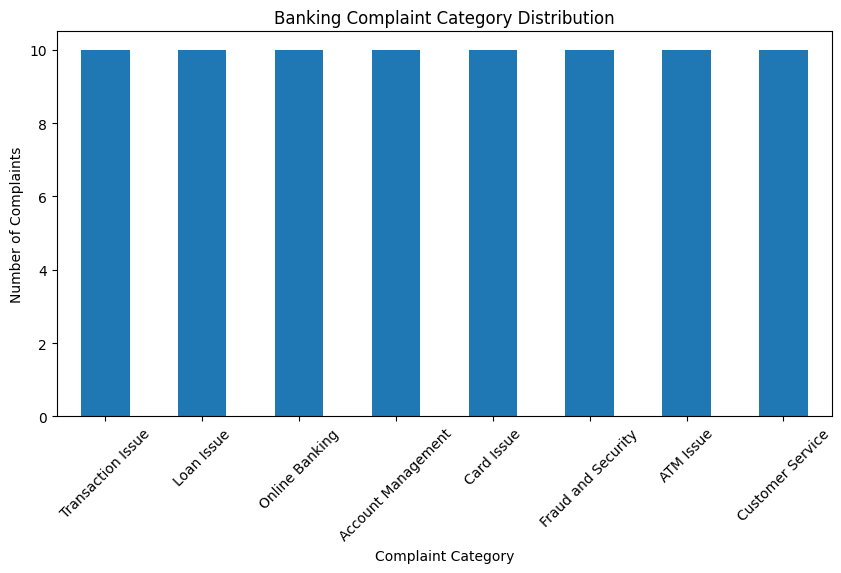

In [39]:
plt.figure(figsize=(10, 5))

df["category"].value_counts().plot(kind="bar")

plt.title("Banking Complaint Category Distribution")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)

plt.show()

## 4. Text Preprocessing

Text preprocessing is an important step in NLP.

The following preprocessing operations are performed:

1. Convert text to lowercase.
2. Remove punctuation.
3. Remove unnecessary numbers and special characters.
4. Remove stopwords.
5. Apply lemmatization.

This helps convert raw customer complaints into cleaner text that can be used by the machine learning model.

In [40]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["cleaned_complaint"] = df["complaint"].apply(preprocess_text)

df.head(10)

,complaint,category,cleaned_complaint
0,My money was deducted but the transaction failed,Transaction Issue,money deducted transaction failed
1,The amount was debited from my account but the...,Transaction Issue,amount debited account receiver get
2,My UPI transaction failed but money was deducted,Transaction Issue,upi transaction failed money deducted
3,I made a payment yesterday but it is still sho...,Transaction Issue,made payment yesterday still showing pending
4,The bank charged me twice for the same transac...,Transaction Issue,bank charged twice transaction
5,My online payment was unsuccessful but the amo...,Transaction Issue,online payment unsuccessful amount deducted
6,The transaction is still pending after several...,Transaction Issue,transaction still pending several hour
7,Money was deducted from my account during a fa...,Transaction Issue,money deducted account failed payment
8,I have not received the refund for my failed t...,Transaction Issue,received refund failed transaction
9,The payment was reversed but the money has not...,Transaction Issue,payment reversed money returned


## 5. Before and After Preprocessing

The original complaint and its processed version are compared to understand the effect of preprocessing.

In [41]:
comparison = df[["complaint", "cleaned_complaint"]].head(10)

comparison

,complaint,cleaned_complaint
0,My money was deducted but the transaction failed,money deducted transaction failed
1,The amount was debited from my account but the...,amount debited account receiver get
2,My UPI transaction failed but money was deducted,upi transaction failed money deducted
3,I made a payment yesterday but it is still sho...,made payment yesterday still showing pending
4,The bank charged me twice for the same transac...,bank charged twice transaction
5,My online payment was unsuccessful but the amo...,online payment unsuccessful amount deducted
6,The transaction is still pending after several...,transaction still pending several hour
7,Money was deducted from my account during a fa...,money deducted account failed payment
8,I have not received the refund for my failed t...,received refund failed transaction
9,The payment was reversed but the money has not...,payment reversed money returned


## 6. Identifying Frequent Banking Issues

The frequency of individual words is analyzed to identify common problems mentioned by customers.

In [42]:
all_words = " ".join(df["cleaned_complaint"]).split()

word_frequency = Counter(all_words)

most_common_words = word_frequency.most_common(20)

word_freq_df = pd.DataFrame(
    most_common_words,
    columns=["Word", "Frequency"]
)

word_freq_df

,Word,Frequency
0,account,17
1,card,15
2,want,11
3,transaction,9
4,loan,9
5,banking,8
6,atm,8
7,payment,7
8,bank,7
9,money,6


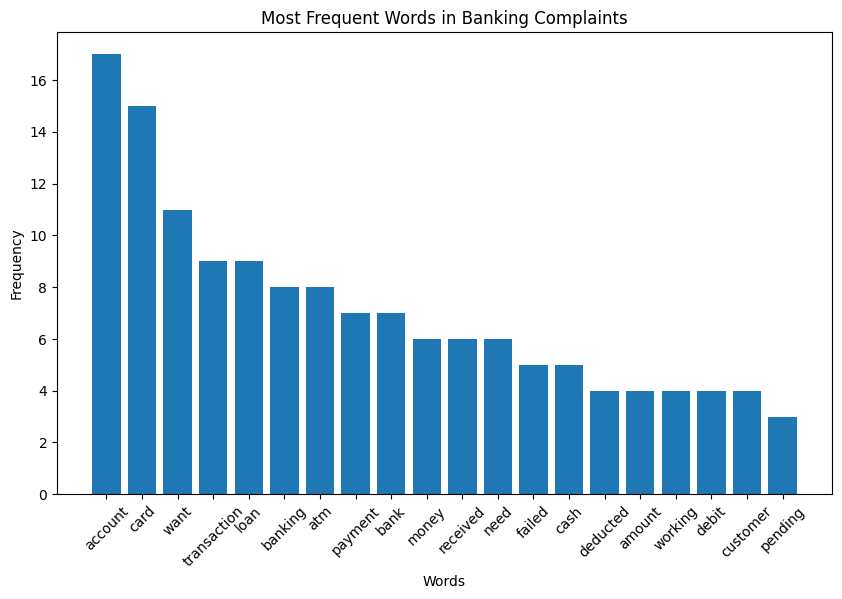

In [43]:
plt.figure(figsize=(10, 6))

plt.bar(
    word_freq_df["Word"],
    word_freq_df["Frequency"]
)

plt.title("Most Frequent Words in Banking Complaints")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

## 7. Complaint Classification Using TF-IDF

TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert complaint text into numerical features.

The TF-IDF representation gives higher importance to words that are useful for distinguishing between different complaint categories.

A Logistic Regression classifier is then trained to categorize customer complaints.

In [44]:
X = df["cleaned_complaint"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 60
Testing samples: 20


In [45]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF Training Shape:", X_train_tfidf.shape)
print("TF-IDF Testing Shape:", X_test_tfidf.shape)

TF-IDF Training Shape: (60, 131)
TF-IDF Testing Shape: (20, 131)


In [46]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


## 8. Model Evaluation

The trained model is evaluated using accuracy, precision, recall, and F1-score.

In [47]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 70.0 %

Classification Report:
                    precision    recall  f1-score   support

         ATM Issue       0.67      1.00      0.80         2
Account Management       0.25      0.50      0.33         2
        Card Issue       1.00      0.67      0.80         3
  Customer Service       1.00      1.00      1.00         3
Fraud and Security       0.00      0.00      0.00         3
        Loan Issue       0.67      1.00      0.80         2
    Online Banking       1.00      1.00      1.00         3
 Transaction Issue       0.50      0.50      0.50         2

          accuracy                           0.70        20
         macro avg       0.64      0.71      0.65        20
      weighted avg       0.66      0.70      0.66        20



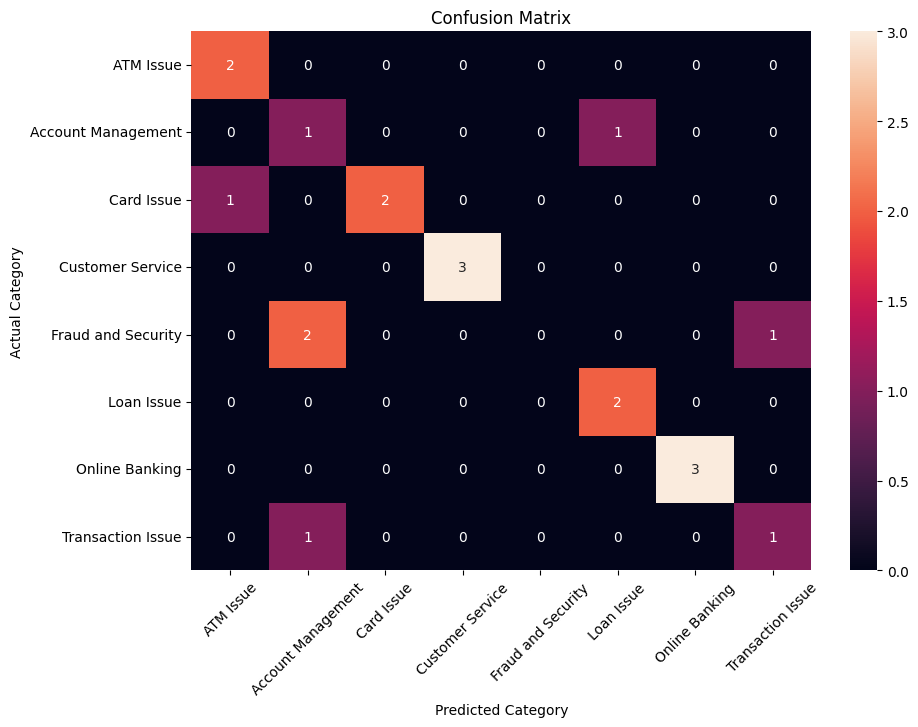

In [48]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

## 9. Testing the System with New Complaints

The trained NLP model can be used to automatically categorize new customer complaints.

In [49]:
new_complaints = [
    "My money was deducted but the payment failed",
    "I cannot login to my mobile banking application",
    "Someone made a transaction from my account without permission",
    "My debit card is not working",
    "The ATM deducted money but did not give me cash",
    "My loan application is still pending"
]

new_cleaned = [preprocess_text(text) for text in new_complaints]

new_tfidf = vectorizer.transform(new_cleaned)

predictions = model.predict(new_tfidf)

results = pd.DataFrame({
    "New Complaint": new_complaints,
    "Predicted Category": predictions
})

results

,New Complaint,Predicted Category
0,My money was deducted but the payment failed,Transaction Issue
1,I cannot login to my mobile banking application,Online Banking
2,Someone made a transaction from my account wit...,Fraud and Security
3,My debit card is not working,Card Issue
4,The ATM deducted money but did not give me cash,ATM Issue
5,My loan application is still pending,Loan Issue


## 10. Category-wise Complaint Analysis

The number of complaints in each category is calculated to identify the areas generating the highest number of customer problems.

In [50]:
category_counts = df["category"].value_counts()

print("Complaint Summary:\n")
print(category_counts)

most_common_category = category_counts.idxmax()

print("\nMost Common Complaint Category:", most_common_category)

Complaint Summary:

category
Transaction Issue     10
Loan Issue            10
Online Banking        10
Account Management    10
Card Issue            10
Fraud and Security    10
ATM Issue             10
Customer Service      10
Name: count, dtype: int64

Most Common Complaint Category: Transaction Issue


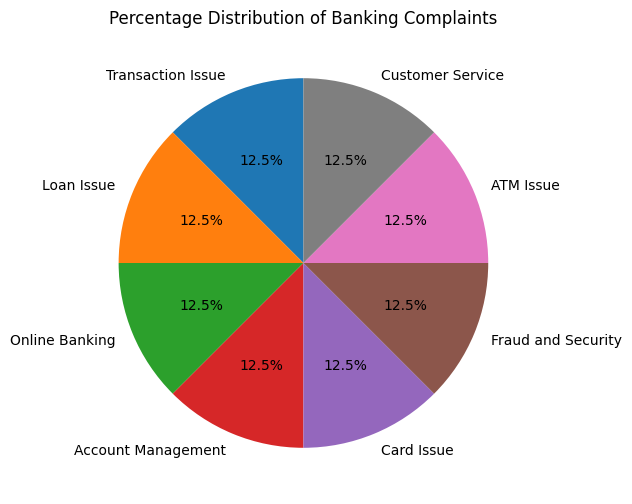

In [51]:
plt.figure(figsize=(10, 6))

category_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Banking Complaints")
plt.ylabel("")

plt.show()

## 11. Automated Analytical Report

Based on the complaint dataset, category distribution and NLP analysis, an automated summary report is generated.

In [52]:
total_complaints = len(df)

category_counts = df["category"].value_counts()

most_common_category = category_counts.idxmax()
highest_count = category_counts.max()

least_common_category = category_counts.idxmin()
lowest_count = category_counts.min()

print("=" * 60)
print("          BANKING COMPLAINT ANALYTICAL REPORT")
print("=" * 60)

print(f"\nTotal Complaints Analyzed: {total_complaints}")

print(f"\nMost Frequent Complaint Category:")
print(f"{most_common_category} ({highest_count} complaints)")

print(f"\nLeast Frequent Complaint Category:")
print(f"{least_common_category} ({lowest_count} complaints)")

print("\nCategory-wise Complaint Count:")
print(category_counts)

print("\nTop 10 Frequently Used Words:")

for word, count in word_frequency.most_common(10):
    print(f"{word}: {count}")

print("\nMachine Learning Model:")
print("TF-IDF + Logistic Regression")

print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

print("\nConclusion:")
print(
    "The NLP system successfully analyzes banking complaints, "
    "categorizes them into different banking issue types, and "
    "identifies frequently occurring customer problems."
)

print("=" * 60)

          BANKING COMPLAINT ANALYTICAL REPORT

Total Complaints Analyzed: 80

Most Frequent Complaint Category:
Transaction Issue (10 complaints)

Least Frequent Complaint Category:
Transaction Issue (10 complaints)

Category-wise Complaint Count:
category
Transaction Issue     10
Loan Issue            10
Online Banking        10
Account Management    10
Card Issue            10
Fraud and Security    10
ATM Issue             10
Customer Service      10
Name: count, dtype: int64

Top 10 Frequently Used Words:
account: 17
card: 15
want: 11
transaction: 9
loan: 9
banking: 8
atm: 8
payment: 7
bank: 7
money: 6

Machine Learning Model:
TF-IDF + Logistic Regression

Model Accuracy: 70.00%

Conclusion:
The NLP system successfully analyzes banking complaints, categorizes them into different banking issue types, and identifies frequently occurring customer problems.


# 12. Conclusion

The Banking Complaint Analysis system demonstrates how Natural Language Processing can be used to analyze customer complaints automatically.

A synthetic banking complaint dataset was created containing complaints from multiple banking categories. The complaint text was cleaned using lowercase conversion, punctuation removal, stopword removal, and lemmatization.

TF-IDF was used to convert the complaint text into numerical features, followed by Logistic Regression for complaint classification. The system was also used to identify frequent words and common complaint categories.

This approach can help banks reduce manual complaint analysis, identify recurring customer problems, and improve the efficiency of customer support operations.

## Future Scope

The system can be further improved by:

- Using a larger real-world banking complaint dataset.
- Applying advanced NLP models such as BERT.
- Adding sentiment analysis.
- Detecting complaint priority automatically.
- Creating a dashboard for customer service teams.
- Integrating the system with a bank's customer support portal.